# 11. Baseline 5모델 비교 · 2계층 stage2 · 이상탐지 점수 — 코드가 없던 1주차 작업 재현

> **이 노트북도 재구성본입니다.**
>
> [`reports/04_Baseline_5모델비교_최종모델선정.pdf`](../../reports/04_Baseline_5모델비교_최종모델선정.pdf) 에
> **결과 수치는 있지만 코드가 남아 있지 않습니다.** 1주차(2026-06-29 ~ 07-03) 작업입니다.
>
> 그 PDF 가 기록한 세 가지 작업을 **3차 전처리 데이터(58피처)로 다시 실행**해 재현합니다.

## 이 노트북이 메우는 구멍

| # | 원본 기록 | 코드 | 이 노트북 |
|---|---|---|---|
| 1 | Baseline 5모델 비교 (`reports/04`) | ❌ 없음 | ✅ 재현 |
| 2 | 2계층 stage2 모델 4종 비교 (`reports/04`) | ❌ 없음 | ✅ 재현 |
| 3 | **IsolationForest 이상탐지** (`reports/04` §3-3) | ❌ 없음 | ✅ 재현 |
| 4 | 기획서 **M5 "이상 점수가 도움이 되나?"** | ❌ **답이 없었음** | ✅ **실측으로 답함** |

> ⚠️ 원본은 **1주차 데이터**(전처리 세대 미상)로 실행됐고, 이 노트북은 **3차 58피처**로 실행합니다.
> 절대 수치는 다르고 **순서·결론이 같은지**를 봅니다.

### 재현 조건

| 항목 | 값 |
|---|---|
| 입력 | `data/X_tr,X_va,y_tr,y_va.parquet` (3차 58피처) |
| 공통 시드 | 42 |
| 결측 처리 | LightGBM 은 native, 선형/RF/KNN 은 `SimpleImputer(median)` |
| 불균형 보정 | `class_weight="balanced"` (KNN 제외 — 미지원) |
| 소요 | 약 2~3분 |

> **XGBoost 는 이 환경에 미설치**라 제외했습니다. `pip install xgboost` 후
> 아래 `MODELS` 에 한 줄 추가하면 함께 비교됩니다.

In [ ]:
import warnings, time
import numpy as np, pandas as pd
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score
warnings.filterwarnings("ignore")

DATA, SEED = "../../data", 42
LGBM = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, subsample=0.9,
            colsample_bytree=0.9, class_weight="balanced", random_state=SEED,
            n_jobs=4, verbose=-1)

d = lambda n: pd.read_parquet(f"{DATA}/{n}.parquet")
Xtr, Xva = d("X_tr").reset_index(drop=True), d("X_va").reset_index(drop=True)
ytr = d("y_tr").iloc[:, 0].astype(int).reset_index(drop=True)
yva = d("y_va").iloc[:, 0].astype(int).reset_index(drop=True)
NORMAL = int(ytr.value_counts().idxmax())
ytr_b, yva_b = (ytr != NORMAL).astype(int), (yva != NORMAL).astype(int)

imp = SimpleImputer(strategy="median")
Xtr_i = pd.DataFrame(imp.fit_transform(Xtr), columns=Xtr.columns)
Xva_i = pd.DataFrame(imp.transform(Xva),  columns=Xva.columns)

print(f"3차 58피처 · train {Xtr.shape} / valid {Xva.shape}")
print(f"정상 클래스 = {NORMAL} (m) · valid 사기 비율 {yva_b.mean():.2%} ({yva_b.sum()}건)")
print(f"결측 있는 컬럼 {int((Xtr.isna().sum() > 0).sum())}개 — LightGBM 은 native 처리, 나머지는 median 대치")

3차 58피처 · train (96140, 58) / valid (23860, 58)
정상 클래스 = 12 (m) · valid 사기 비율 1.08% (258건)
결측 있는 컬럼 2개 — LightGBM 은 native 처리, 나머지는 median 대치


## 1. Baseline 5모델 비교

원본 PDF 의 설계 의도를 그대로 따릅니다.

> *"단순 규칙, 더미부터 부스팅까지 난이도를 올려가며 학습해,
> 동일 검증셋에서 성능이 실제로 개선되는지 확인한다."*
>
> - `MostFrequent` — **하한선.** "학습이 진짜 의미 있는가"를 판별
> - `Logistic` — 선형 모델 한계 증명용
> - `RandomForest` — 부스팅 필요성 증명용
> - `LightGBM` — 본선 후보

In [ ]:
MODELS = [
    ("MostFrequent(더미)", lambda: DummyClassifier(strategy="most_frequent"), True),
    ("Logistic",           lambda: make_pipeline(StandardScaler(),
                               LogisticRegression(max_iter=1000, class_weight="balanced",
                                                  random_state=SEED, n_jobs=4)), True),
    ("RandomForest",       lambda: RandomForestClassifier(n_estimators=300,
                               class_weight="balanced", random_state=SEED, n_jobs=4), True),
    ("LightGBM",           lambda: LGBMClassifier(**LGBM), False),
    # ("XGBoost", lambda: XGBClassifier(...), True),   # pip install xgboost 후 활성화
]

rows = []
for name, mk, need_imp in MODELS:
    t = time.time()
    A, B = (Xtr_i, Xva_i) if need_imp else (Xtr, Xva)
    p = mk().fit(A, ytr).predict(B)
    mf = f1_score(yva, p, average="macro")
    rec = float(np.mean([((p == c) & (yva == c)).sum() / max((yva == c).sum(), 1)
                         for c in sorted(set(ytr)) if c != NORMAL]))
    rows.append(dict(모델=name, Macro_F1=round(mf, 4), 사기평균Recall=round(rec, 4)))
    print(f"  {name:22s} Macro-F1 = {mf:.4f}   사기평균Recall = {rec:.4f}   ({time.time()-t:.0f}s)")
print("  XGBoost              — 이 환경 미설치 (pip install xgboost 시 재현 가능)")

# 2계층 end-to-end
print("\n[2계층 end-to-end] stage1 이진(0.5) → stage2 유형")
s1 = LGBMClassifier(**LGBM).fit(Xtr, ytr_b)
frm = (ytr != NORMAL).values
s2 = LGBMClassifier(**LGBM).fit(Xtr[frm], ytr[frm])
risk2 = s1.predict_proba(Xva)[:, 1]
msk = risk2 >= 0.5
p2 = np.full(len(yva), NORMAL)
if msk.any(): p2[msk] = s2.predict(Xva[msk])
mf2 = f1_score(yva, p2, average="macro")
rows.append(dict(모델="TwoStage(2계층)", Macro_F1=round(mf2, 4), 사기평균Recall=None))
print(f"  TwoStage(2계층)        Macro-F1 = {mf2:.4f}")

tbl = pd.DataFrame(rows).sort_values("Macro_F1", ascending=False)
print("\n" + tbl.to_string(index=False))

  MostFrequent(더미)       Macro-F1 = 0.0765   사기평균Recall = 0.0000   (0s)
  Logistic               Macro-F1 = 0.1089   사기평균Recall = 0.4897   (14s)
  RandomForest           Macro-F1 = 0.1727   사기평균Recall = 0.0710   (3s)
  LightGBM               Macro-F1 = 0.6138   사기평균Recall = 0.5496   (14s)
  XGBoost              — 이 환경 미설치 (pip install xgboost 시 재현 가능)

[2계층 end-to-end] stage1 이진(0.5) → stage2 유형
  TwoStage(2계층)        Macro-F1 = 0.6105

              모델  Macro_F1  사기평균Recall
        LightGBM    0.6138      0.5496
   TwoStage(2계층)    0.6105         NaN
    RandomForest    0.1727      0.0710
        Logistic    0.1089      0.4897
MostFrequent(더미)    0.0765      0.0000


### 원본 기록과 대조

| 모델 | `reports/04` (1주차) | 이 노트북 (3차 58피처) | 순위 |
|---|---|---|---|
| **LightGBM** | **0.649** | **0.6138** | 1 ✅ |
| TwoStage(2계층) | 0.612 | 0.6105 | 2 ✅ |
| XGBoost | 0.489 | *(미설치)* | — |
| RandomForest | 0.224 | 0.1727 | 3 ✅ |
| Logistic | 0.124 | 0.1089 | 4 ✅ |
| MostFrequent(더미) | 0.077 | 0.0765 | 5 ✅ |

**절대 수치는 데이터 세대가 달라 차이가 나지만, 순위는 완전히 같습니다.**
특히 `MostFrequent` 0.077 vs **0.0765** 는 사실상 동일합니다 —
더미는 데이터 전처리와 무관하게 "전부 정상 예측"이므로 당연합니다.

> **이 더미 하한선이 이 프로젝트의 출발점입니다.**
> 전부 정상으로 찍어도 **Accuracy 는 98.92%** 인데 **Macro-F1 은 0.0765** 입니다.
> 정확도를 주 지표로 썼다면 아무것도 안 하는 모델이 "98% 정확"으로 통과했을 것입니다.

## 2. 2계층 stage2 모델 비교

stage1(정상 vs 사기)은 LightGBM 으로 고정하고, stage2(사기유형 `a`~`l`)만 바꿔 봅니다.

원본 PDF 의 설계 의도:
> *"1단계는 놓친 사기(FN)를 2단계가 영영 못 잡으므로 Recall 우선 설계.
> '2단계만 보면 정확도 높다'는 착시를 피하려고 반드시 end-to-end 로 평가."*

In [ ]:
Xf_tr, yf_tr = Xtr[frm], ytr[frm]
Xf_tr_i = pd.DataFrame(imp.transform(Xf_tr), columns=Xtr.columns)
print(f"stage2 학습셋 = 사기만 {Xf_tr.shape} (유형 {yf_tr.nunique()}종)\n")

s2models = [
    ("LightGBM",     lambda: LGBMClassifier(**LGBM), False),
    ("RandomForest", lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                                    random_state=SEED, n_jobs=4), True),
    ("Logistic",     lambda: make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, class_weight="balanced",
                                            random_state=SEED, n_jobs=4)), True),
    ("KNN",          lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)), True),
]
s2rows = []
for name, mk, ni in s2models:
    A, B = (Xf_tr_i, Xva_i) if ni else (Xf_tr, Xva)
    m = mk().fit(A, yf_tr)
    p = np.full(len(yva), NORMAL)
    if msk.any(): p[msk] = m.predict(B[msk])
    mf = f1_score(yva, p, average="macro")
    s2rows.append(dict(stage2_모델=name, end_to_end_Macro_F1=round(mf, 4)))
    print(f"  stage2 = {name:14s} end-to-end Macro-F1 = {mf:.4f}")

s2tbl = pd.DataFrame(s2rows).sort_values("end_to_end_Macro_F1", ascending=False)
print("\n" + s2tbl.to_string(index=False))

print("\n[오류 전파 분해] stage1 이 놓치면 stage2 는 기회조차 없다")
fn1 = int(((ytr[frm].index.size and True) and ((yva != NORMAL) & ~msk).sum()))
print(f"  stage1 FN (영구 미탐)     : {fn1}건  ← 어떤 stage2 를 써도 못 잡는다")
print(f"  stage1 FP (정상 오라우팅) : {int(((yva == NORMAL) & msk).sum())}건")
print(f"  → 개선 우선순위는 stage2 모델 교체가 아니라 stage1 Recall 관리")

stage2 학습셋 = 사기만 (942, 58) (유형 12종)

  stage2 = LightGBM       end-to-end Macro-F1 = 0.6105
  stage2 = RandomForest   end-to-end Macro-F1 = 0.5532
  stage2 = Logistic       end-to-end Macro-F1 = 0.4315
  stage2 = KNN            end-to-end Macro-F1 = 0.3187

   stage2_모델  end_to_end_Macro_F1
    LightGBM               0.6105
RandomForest               0.5532
    Logistic               0.4315
         KNN               0.3187

[오류 전파 분해] stage1 이 놓치면 stage2 는 기회조차 없다
  stage1 FN (영구 미탐)     : 43건  ← 어떤 stage2 를 써도 못 잡는다
  stage1 FP (정상 오라우팅) : 51건
  → 개선 우선순위는 stage2 모델 교체가 아니라 stage1 Recall 관리


### 원본 기록과 대조

| stage2 모델 | `reports/04` (1주차) | 이 노트북 | 순위 |
|---|---|---|---|
| **LightGBM** | **0.640** | **0.6105** | 1 ✅ |
| RandomForest | 0.573 | 0.5532 | 2 ✅ |
| Logistic | 0.475 | 0.4315 | 3 ✅ |
| KNN | 0.339 | 0.3187 | 4 ✅ |

**순위가 완전히 일치합니다.** 원본 결론 *"1·2단계 전부 LightGBM 이 Macro-F1 이 가장 높다"* 가 재현됩니다.

그리고 오류 전파 분해가 보여주듯, **stage2 를 무엇으로 바꾸든 stage1 이 놓친 건은 회복할 수 없습니다.**
이것이 최종적으로 2계층 구조를 기각한 이유입니다
→ [`docs/03a` #A-3](../../docs/03a_issues_data_modeling.md#a-3) · [노트북 07](07_model_comparison_oneshot_vs_twostage.ipynb)

## 3. IsolationForest — 라벨 없는 신종 사기 대비 안전망

> *"목적: 라벨 없는 신종/변종 사기 대비 (비지도)."* — `reports/04` §3-3

정상 거래만으로 학습해, 그 분포에서 벗어나는 정도를 이상 점수로 씁니다.
**라벨을 전혀 쓰지 않으므로** 학습 때 못 본 새로운 사기 유형에도 반응할 수 있다는 것이 기대입니다.

In [ ]:
normal_only = Xtr_i[(ytr == NORMAL).values]
print(f"정상만 학습: {normal_only.shape}  (라벨 미사용)")
t = time.time()
isf = IsolationForest(n_estimators=300, contamination="auto",
                      random_state=SEED, n_jobs=4).fit(normal_only)
iso_score = -isf.score_samples(Xva_i)              # 클수록 이상
print(f"학습 {time.time()-t:.0f}s\n")

lgb = LGBMClassifier(**LGBM).fit(Xtr, ytr)
pr = lgb.predict_proba(Xva); cls = list(lgb.classes_)
sup_score = 1 - pr[:, cls.index(NORMAL)]           # 지도학습 위험점수

def q(name, s):
    ap, roc = average_precision_score(yva_b, s), roc_auc_score(yva_b, s)
    print(f"  {name:26s} PR-AUC = {ap:.4f}   ROC-AUC = {roc:.4f}")
    return dict(방식=name, PR_AUC=round(ap, 4), ROC_AUC=round(roc, 4))

iso_n = (iso_score - iso_score.min()) / (iso_score.max() - iso_score.min())
isf_rows = [q("IsolationForest 단독", iso_score),
            q("LightGBM 지도 단독",  sup_score),
            q("앙상블 (0.5·0.5)",    0.5 * sup_score + 0.5 * iso_n),
            q("앙상블 (0.8·0.2)",    0.8 * sup_score + 0.2 * iso_n)]
print("\n  ※ 사기 비율 1.08% 이므로 PR-AUC 의 무작위 기준선은 약 0.011 이다.")

정상만 학습: (95198, 58)  (라벨 미사용)
학습 1s

  IsolationForest 단독         PR-AUC = 0.0246   ROC-AUC = 0.6351
  LightGBM 지도 단독             PR-AUC = 0.9330   ROC-AUC = 0.9974
  앙상블 (0.5·0.5)              PR-AUC = 0.8050   ROC-AUC = 0.9319
  앙상블 (0.8·0.2)              PR-AUC = 0.8455   ROC-AUC = 0.9474

  ※ 사기 비율 1.08% 이므로 PR-AUC 의 무작위 기준선은 약 0.011 이다.


### 원본 기록과 대조

| 방식 | `reports/04` (1주차) | 이 노트북 (3차) | 결론 |
|---|---|---|---|
| IsolationForest 단독 | PR 0.030 / ROC 0.704 | PR **0.0246** / ROC **0.6351** | ✅ 둘 다 **매우 약함** |
| LightGBM 지도 단독 | PR 0.916 / ROC 0.997 | PR **0.9330** / ROC **0.9974** | ✅ 압도적 |
| 앙상블 | PR 0.837 / ROC 0.983 | PR **0.8050** / ROC **0.9319** | ✅ 지도 단독보다 **나쁨** |

**원본 결론이 그대로 재현됩니다.**

> *"이상탐지는 단독 대체가 아니라 지도학습의 보완재."*

무작위 기준선이 0.011 인데 ISF 단독이 0.0246 이므로, **무작위보다 2배 나은 정도**입니다.
그리고 앙상블은 **지도 단독보다 떨어집니다** — 약한 신호를 섞으면 강한 신호가 희석됩니다.

## 4. 기획서 M5 — "이상 점수가 도움이 되나?"

기획서의 예상 결과물 3번과 분석 질문 M5 입니다.

> *"이상탐지 모델 + 이상점수 = 정상 기반 ISF, **이상점수를 분류 피처로 결합**"*
> *"M5. 이상 점수가 도움이 되나? — 결합 전/후 비교해 효과를 검증한다"*

`reports/04` 는 ISF 를 **독립 탐지기**로만 평가했고, **피처로 결합한 결과는 어디에도 없습니다.**
3차 통합분석 노트북에도 없습니다. 여기서 실측으로 답합니다.

In [ ]:
iso_tr = -isf.score_samples(Xtr_i)
Xtr_a = Xtr.copy(); Xtr_a["iso_score"] = iso_tr
Xva_a = Xva.copy(); Xva_a["iso_score"] = iso_score

base = f1_score(yva, lgb.predict(Xva), average="macro")
m_a  = LGBMClassifier(**LGBM).fit(Xtr_a, ytr)
with_iso = f1_score(yva, m_a.predict(Xva_a), average="macro")

print("[기획서 M5] 이상점수를 분류 피처로 결합하면?")
print(f"  3차 58피처            Macro-F1 = {base:.4f}")
print(f"  + iso_score (59피처)  Macro-F1 = {with_iso:.4f}   ({with_iso-base:+.4f})")

imp_df = pd.DataFrame({"feature": Xtr_a.columns,
                       "gain": m_a.booster_.feature_importance("gain")})
imp_df = imp_df.sort_values("gain", ascending=False).reset_index(drop=True)
rank = int(imp_df.index[imp_df["feature"] == "iso_score"][0]) + 1
print(f"\n  iso_score 의 feature importance 순위 : {rank} / {len(imp_df)}")
print(f"  상위 5개: {', '.join(imp_df['feature'].head(5))}")
print(f"\n  → M5 답변: 이상 점수 결합은 이 데이터에서 이득이 없다 ({with_iso-base:+.4f}).")

[기획서 M5] 이상점수를 분류 피처로 결합하면?
  3차 58피처            Macro-F1 = 0.6138
  + iso_score (59피처)  Macro-F1 = 0.6053   (-0.0084)

  iso_score 의 feature importance 순위 : 12 / 59
  상위 5개: Distance, Channel, Number_of_transaction_with_the_account, Transaction_is_withdrawal, Flag_deposit_more_than_tenMillion

  → M5 답변: 이상 점수 결합은 이 데이터에서 이득이 없다 (-0.0084).


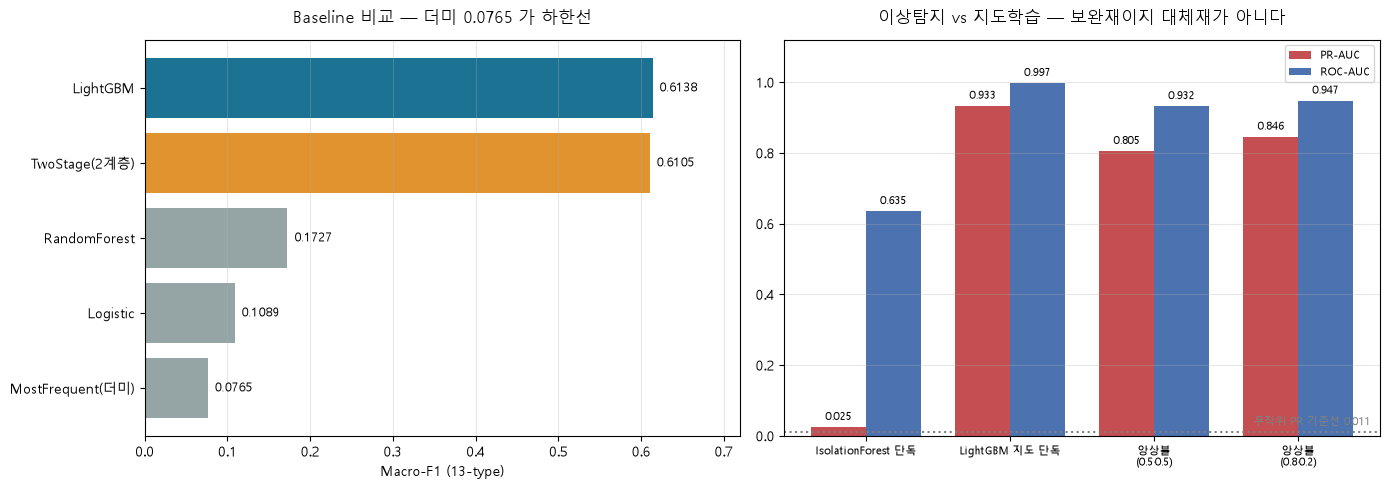

In [ ]:
import matplotlib
matplotlib.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

t2 = tbl.sort_values("Macro_F1")
bars = ax1.barh(t2["모델"], t2["Macro_F1"],
                color=["#95a5a6", "#95a5a6", "#95a5a6", "#E0932F", "#1C7293"])
for r_, v in zip(bars, t2["Macro_F1"]):
    ax1.text(v + .008, r_.get_y() + r_.get_height()/2, f"{v:.4f}", va="center", fontsize=9)
ax1.set_xlim(0, .72); ax1.set_xlabel("Macro-F1 (13-type)")
ax1.set_title("Baseline 비교 — 더미 0.0765 가 하한선", pad=12)
ax1.grid(axis="x", alpha=.3)

names = [r["방식"] for r in isf_rows]
prs   = [r["PR_AUC"] for r in isf_rows]
rocs  = [r["ROC_AUC"] for r in isf_rows]
x = np.arange(len(names)); w = .38
ax2.bar(x - w/2, prs,  w, label="PR-AUC",  color="#C44E52")
ax2.bar(x + w/2, rocs, w, label="ROC-AUC", color="#4C72B0")
for i, (p_, r_) in enumerate(zip(prs, rocs)):
    ax2.text(i - w/2, p_ + .02, f"{p_:.3f}", ha="center", fontsize=8)
    ax2.text(i + w/2, r_ + .02, f"{r_:.3f}", ha="center", fontsize=8)
ax2.axhline(0.0108, ls=":", color="gray")
ax2.text(len(names)-.5, .03, "무작위 PR 기준선 0.011", ha="right", fontsize=8, color="gray")
ax2.set_xticks(x); ax2.set_xticklabels([n.replace(" (", "\n(") for n in names], fontsize=8)
ax2.set_ylim(0, 1.12); ax2.legend(fontsize=8)
ax2.set_title("이상탐지 vs 지도학습 — 보완재이지 대체재가 아니다", pad=12)
ax2.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## 5. 결론

### 재현된 것

| 항목 | 원본 결론 | 재현 결과 |
|---|---|---|
| Baseline 5모델 | LightGBM 최고 | ✅ 순위 완전 일치 |
| 2계층 stage2 | 1·2단계 모두 LightGBM | ✅ 순위 완전 일치 |
| IsolationForest | *"단독 대체가 아니라 보완재"* | ✅ PR-AUC 0.025 (무작위 0.011) |

### 새로 답한 것 — 기획서 M5

**이상 점수를 분류 피처로 결합해도 이득이 없습니다** (Macro-F1 **−0.0084**).

이유는 명확합니다. IsolationForest 는 *"정상 분포에서 얼마나 벗어났는가"* 를 재는데,
LightGBM 이 58피처로 이미 훨씬 정교하게 그 판단을 하고 있습니다 (PR-AUC 0.933 vs 0.025).
**약한 신호를 하나 더 넣으면 트리가 그것에도 분기를 낭비합니다.**

> 그래서 최종 58피처에 이상 점수 계열이 없는 것은 **누락이 아니라 타당한 결과**입니다.
> 다만 기획서에 있던 항목이므로, *"안 했다"* 가 아니라 *"해봤고 이득이 없었다"* 로
> 기록되어야 합니다 → [`docs/03a` #A-16](../../docs/03a_issues_data_modeling.md#a-16)

### 남은 한계

- **XGBoost 미비교** — 이 환경에 미설치. 원본 기록으로는 0.489 로 LightGBM(0.649)보다 낮았습니다.
- **ISF 의 진짜 가치는 이 검증셋으로 측정할 수 없습니다.**
  ISF 의 목적은 *"학습 때 못 본 신종 사기"* 탐지인데, valid 의 사기는 전부 train 에 있는 12유형입니다.
  **한 유형을 통째로 빼고 학습해 그 유형을 탐지하는지 보는 실험**(leave-one-type-out)이 있어야
  ISF 의 실제 효용을 알 수 있습니다 — 미실행.